In [1]:
#PATIENT READMISSION

In [2]:
#Upload Dataset
import pandas as pd

df = pd.read_csv("diabetic_data.csv")

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
#Shape of the data
df.shape

(101766, 50)

In [4]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [7]:
#Data Cleaning

In [8]:
#Replace "?" with NaN
import numpy as np
df.replace("?", np.nan, inplace=True)

In [9]:
#Checked missing values
df.isnull().sum().sort_values(ascending=False)

weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
troglitazone                    0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
citoglipton                     0
tolazamide                      0
examide                         0
glipizide                       0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glyburide                       0
repaglinide   

In [10]:
#Drop Useless Columns
df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

In [11]:
#Drop High-Missing Columns
df.drop(['weight', 'payer_code', 'medical_specialty'], axis=1, inplace=True)

In [12]:
#Handle Remaining Missing Values
df.fillna(df.mode().iloc[0], inplace=True)

In [13]:
#Convert Target Variable
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

In [14]:
#Convert Categorical to Numeric
df = pd.get_dummies(df, drop_first=True)

In [15]:
#Final Check
df.isnull().sum().sum()

0

In [16]:
df.shape

(101766, 2331)

In [17]:
#EDA
#What drives readmissions
#Patterns in the data
#Relationships between variables

In [18]:
#Check Target Distribution
df['readmitted'].value_counts()

readmitted
0    90409
1    11357
Name: count, dtype: int64

In [19]:
df['readmitted'].value_counts(normalize=True)

readmitted
0    0.888401
1    0.111599
Name: proportion, dtype: float64

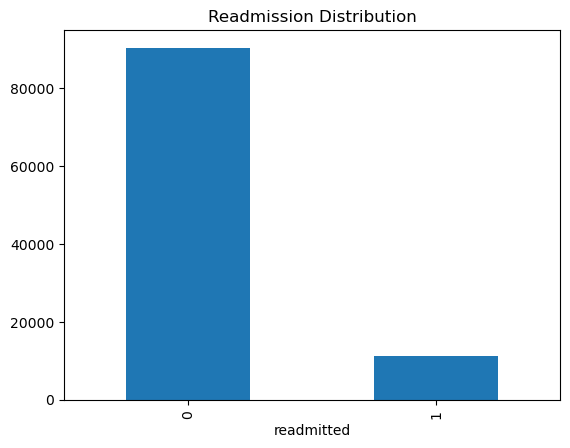

In [20]:
#Visualize Target
import matplotlib.pyplot as plt
df['readmitted'].value_counts().plot(kind='bar')
plt.title("Readmission Distribution")
plt.show()

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
df = pd.read_csv("diabetic_data.csv")

# Cleaning (but skip encoding)
df.replace("?", np.nan, inplace=True)
df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)
df.drop(['weight', 'payer_code', 'medical_specialty'], axis=1, inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)

# Convert target
df['readmitted'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

<Axes: xlabel='age'>

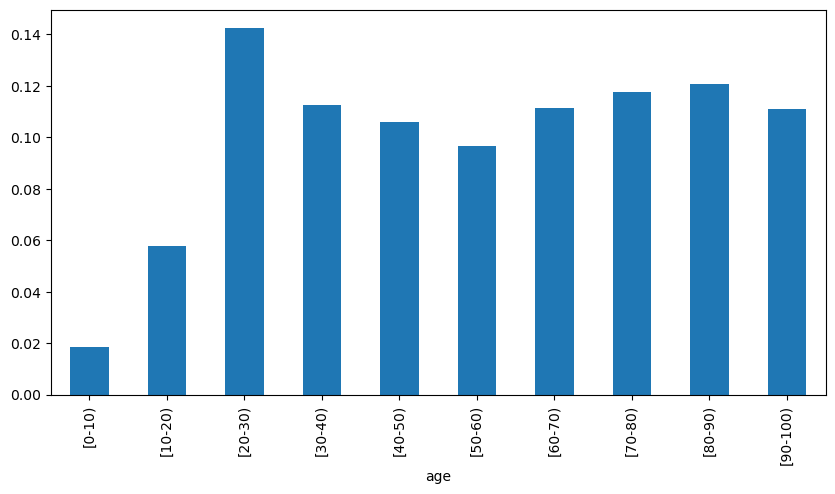

In [23]:
df.groupby('age')['readmitted'].mean().plot(kind='bar', figsize=(10,5))

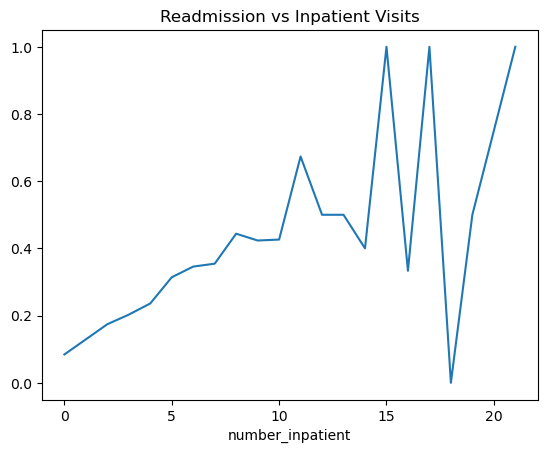

In [24]:
#Visits vs Readmission
df.groupby('number_inpatient')['readmitted'].mean().plot()
plt.title("Readmission vs Inpatient Visits")
plt.show()

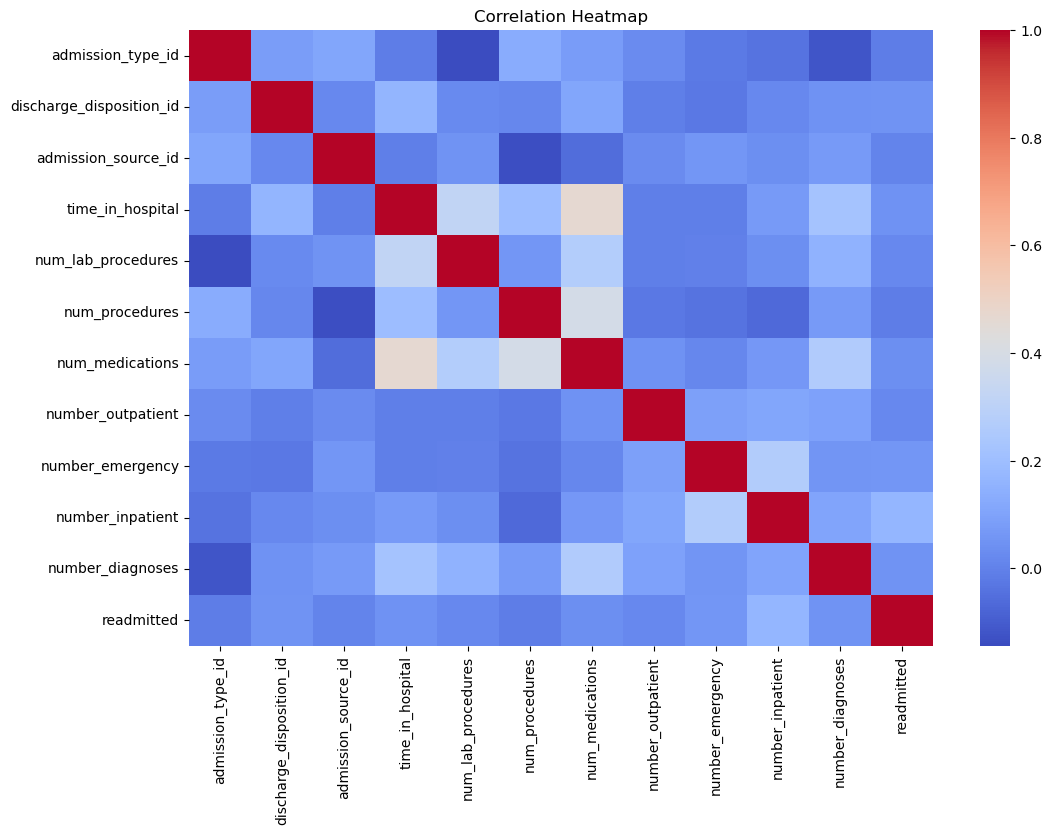

In [25]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df_numeric.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [26]:
#Top Correlated Features
df_numeric = df.select_dtypes(include=['int64', 'float64'])

corr = df_numeric.corr()['readmitted'].sort_values(ascending=False)

corr.head(10)

readmitted                  1.000000
number_inpatient            0.165147
number_emergency            0.060747
discharge_disposition_id    0.050560
number_diagnoses            0.049524
time_in_hospital            0.044199
num_medications             0.038432
num_lab_procedures          0.020364
number_outpatient           0.018893
admission_source_id         0.005820
Name: readmitted, dtype: float64

In [27]:
#STEP 4 FEATURE ENGINEERING
#Created total_visits feature
#Simplified age into groups
#Added high utilization indicator
#Created long stay and chronic flags
#Total Visits (VERY IMPORTANT)
df['total_visits'] = (
    df['number_inpatient'] +
    df['number_outpatient'] +
    df['number_emergency']
)

In [28]:
#Age Group Simplification
def simplify_age(age):
    if age in ['[0-10]', '[10-20]', '[20-30]']:
        return 'young'
    elif age in ['[30-40]', '[40-50]', '[50-60]']:
        return 'middle'
    else:
        return 'old'

df['age_group'] = df['age'].apply(simplify_age)

In [29]:
#High Utilization Flag
df['high_utilization'] = df['total_visits'].apply(lambda x: 1 if x > 3 else 0)

In [30]:
#Long Stay Flag
df['long_stay'] = df['time_in_hospital'].apply(lambda x: 1 if x > 7 else 0)

In [31]:
#Chronic Indicator
df['chronic_flag'] = df['num_lab_procedures'].apply(lambda x: 1 if x > 40 else 0)
#Quick Validation (IMPORTANT)
df.groupby('age_group')['readmitted'].mean()
df.groupby('high_utilization')['readmitted'].mean()

#NOW Encode (Important Timing)
df = pd.get_dummies(df, drop_first=True)

#Final Check
df.isnull().sum().sum()


0

In [32]:
#STEP 5 -Model Building
#Define Features & Target
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [33]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
#Logistic Regression (Baseline Model)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

C:\Users\manal\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [35]:
X_train.dtypes

admission_type_id                  int64
discharge_disposition_id           int64
admission_source_id                int64
time_in_hospital                   int64
num_lab_procedures                 int64
                                   ...  
glimepiride-pioglitazone_Steady     bool
metformin-rosiglitazone_Steady      bool
metformin-pioglitazone_Steady       bool
change_No                           bool
diabetesMed_Yes                     bool
Length: 2334, dtype: object

In [36]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [37]:
X_train.fillna(0, inplace=True)
X_test.fillna(0, inplace=True)

In [38]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

C:\Users\manal\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [39]:
#Prediction
y_pred_lr = lr.predict(X_test)

In [40]:
#Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


[[18020    49]
 [ 2250    35]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.42      0.02      0.03      2285

    accuracy                           0.89     20354
   macro avg       0.65      0.51      0.48     20354
weighted avg       0.84      0.89      0.84     20354



In [41]:
#ROC-AUC Score
roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

0.6435330988080822

In [42]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[18063     6]
 [ 2277     8]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.57      0.00      0.01      2285

    accuracy                           0.89     20354
   macro avg       0.73      0.50      0.47     20354
weighted avg       0.85      0.89      0.84     20354



In [43]:
# Model Building

#Trained Logistic Regression as baseline
#Used Random Forest for improved performance
#Evaluated using confusion matrix, recall, and ROC-AUC

In [44]:
#Prepare data
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [45]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
#Train Model - Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\manal\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [47]:
#Predictions
y_pred = model.predict(X_test)

In [48]:
#Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18020    49]
 [ 2250    35]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.42      0.02      0.03      2285

    accuracy                           0.89     20354
   macro avg       0.65      0.51      0.48     20354
weighted avg       0.84      0.89      0.84     20354



In [49]:
#ROC-AUC Score
roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

0.6435330988080822

In [50]:
#To catch high risk patient not just accuracy
#Random Forest (strong model)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.60      0.00      0.01      2285

    accuracy                           0.89     20354
   macro avg       0.74      0.50      0.47     20354
weighted avg       0.86      0.89      0.84     20354



In [51]:
#6 — Model Explainability
#Feature Importance (Random Forest)
import pandas as pd

importance = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

feat_imp.head(10)

num_lab_procedures          0.050261
num_medications             0.046816
time_in_hospital            0.035573
num_procedures              0.026176
discharge_disposition_id    0.026109
number_diagnoses            0.025095
total_visits                0.024194
number_inpatient            0.023748
admission_type_id           0.020955
admission_source_id         0.018035
dtype: float64

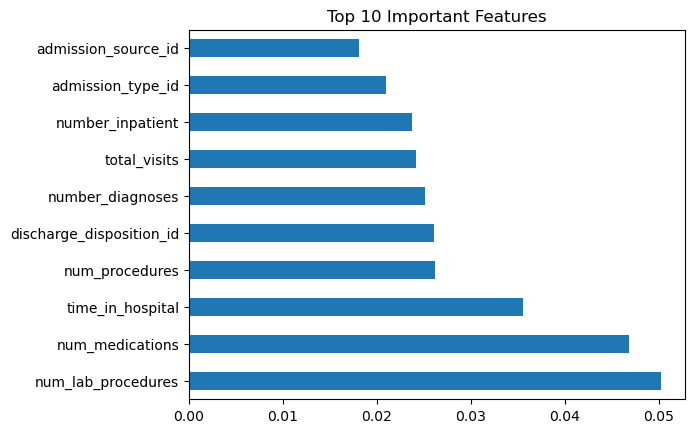

In [52]:
import matplotlib.pyplot as plt

feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [53]:
# Model Insights
#Patients with higher hospital visits are more likely to be readmitted  
#Longer hospital stays increase readmission risk  
#Lab procedures indicate chronic conditions  

In [54]:
!pip install shap

INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     --------------------------------- ------ 51.2/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   --------------------------------- ----- 481.3/556.1 kB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 556.1/556.1 kB 8.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --------------- ------------------------ 1.1/2.8 MB 22.7 MB/s eta 0:00:01
   -------------------- ------------------- 1.4/2.8 MB 21.8 MB/s eta 0:00:01
   ---------------------------------------  2.7/2.8 MB 21.9 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 17.5 MB/s eta 0:00:00
   ----------------------

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.


In [55]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[1], X_test)

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.12 from "C:\Users\manal\Anaconda\python.exe"
  * The NumPy version is: "1.26.4"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: numpy._core.multiarray failed to import

In [61]:
rf.feature_importances_

array([2.09554389e-02, 2.61088435e-02, 1.80347246e-02, ...,
       1.48413221e-07, 9.97836074e-03, 6.13321781e-03])

In [62]:
df.to_csv(r"C:\Users\manal\Downloads\final_data.csv", index=False)
print("File saved successfully!")

File saved successfully!


In [63]:
df.to_csv(r"C:\Users\manal\Downloads\final_data.csv", index=False)
print("File saved successfully!")

File saved successfully!
